In [ ]:
!pip install -U transformers accelerate bitsandbytes peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 26.9 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
  Attempting uninstall: peft
    Found existing installation: peft 0.18.1
    Uninstalling peft-0.18.1:
      Successfully uninstalled peft-0.18.1


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

model_name = "mistralai/Mistral-7B-Instruct-v0.1"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

In [ ]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 3,407,872 || all params: 7,245,139,968 || trainable%: 0.0470


In [ ]:
import json
import random

roles = [
    ("Backend Developer", ["Node.js", "MongoDB", "API Design"]),
    ("Frontend Developer", ["React", "CSS", "Performance"]),
    ("ML Engineer", ["ML Models", "Data", "Optimization"]),
    ("DevOps Engineer", ["CI/CD", "Docker", "Kubernetes"])
]

depths = ["Light", "Medium", "Deep"]

questions = {
    "Backend Developer": [
        "Explain how REST APIs work",
        "How does Node.js handle concurrency",
        "What is database indexing"
    ],
    "Frontend Developer": [
        "What is virtual DOM",
        "How do you optimize React apps",
        "What are hooks"
    ],
    "ML Engineer": [
        "What is overfitting",
        "Explain gradient descent",
        "What is feature engineering"
    ],
    "DevOps Engineer": [
        "What is CI/CD",
        "What is Docker",
        "Explain Kubernetes basics"
    ]
}

followups = [
    "Can you go deeper into that?",
    "What are trade-offs?",
    "How would you optimize this?",
    "Can you give a real-world example?"
]

data = []

for _ in range(200):
    role, skills = random.choice(roles)
    depth = random.choice(depths)
    q = random.choice(questions[role])
    f = random.choice(followups)

    sample1 = {
        "text": f"<s>[INST] Start interview for {role} ({depth}) with {', '.join(skills)} [/INST] {q}?</s>"
    }

    sample2 = {
        "text": f"<s>[INST] Candidate: Answer about {q} [/INST] {f}</s>"
    }

    data.append(sample1)
    data.append(sample2)

with open("interview_data.jsonl", "w") as f:
    for item in data:
        f.write(json.dumps(item) + "\n")

print("Dataset generated!")

Dataset generated!


In [ ]:
from datasets import load_dataset

dataset = load_dataset("json", data_files="interview_data.jsonl")

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 400
    })
})

In [ ]:
tokenizer.pad_token = tokenizer.eos_token

def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=512
    )

dataset = dataset.map(tokenize)

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

In [ ]:
from transformers import TrainingArguments
from trl import SFTTrainer

training_args = TrainingArguments(
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    num_train_epochs=1,
    logging_steps=10,
    output_dir="./results",
    save_strategy="no"
)

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset["train"],
    args=training_args,
)

trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
10,0.364921
20,0.203009
30,0.123625
40,0.087733
50,0.076663


TrainOutput(global_step=50, training_loss=0.1711902391910553, metrics={'train_runtime': 664.1197, 'train_samples_per_second': 0.602, 'train_steps_per_second': 0.075, 'total_flos': 8741766719078400.0, 'train_loss': 0.1711902391910553})

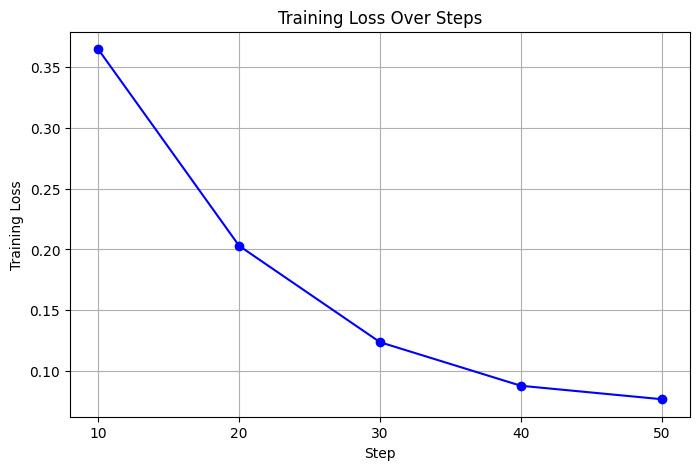

In [ ]:
import matplotlib.pyplot as plt

steps = [10, 20, 30, 40, 50]
training_loss = [0.364921, 0.203009, 0.123625, 0.087733, 0.076663]

plt.figure(figsize=(8, 5))
plt.plot(steps, training_loss, marker='o', linestyle='-', color='b')
plt.title('Training Loss Over Steps')
plt.xlabel('Step')
plt.ylabel('Training Loss')
plt.grid(True)
plt.xticks(steps)
plt.show()

### Model Inference: Demonstrating the fine-tuned model
Let's test our fine-tuned model with a sample interview question to see how it responds.

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import torch

# Load the base model again if it's not already loaded or if the session restarted
# Ensure the bnb_config is defined as before if the model is being reloaded

model_name = "mistralai/Mistral-7B-Instruct-v0.1"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

# Reload the base model in 4-bit
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained("interview-bot-lora")

# Load the fine-tuned LoRA adapters onto the base model
fine_tuned_model = PeftModel.from_pretrained(base_model, "interview-bot-lora")

# Set the model to evaluation mode
fine_tuned_model.eval()

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): MistralForCausalLM(
      (model): MistralModel(
        (embed_tokens): Embedding(32000, 4096)
        (layers): ModuleList(
          (0-31): 32 x MistralDecoderLayer(
            (self_attn): MistralAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj)

In [ ]:
model.save_pretrained("interview-bot-lora")
tokenizer.save_pretrained("interview-bot-lora")

('interview-bot-lora/tokenizer_config.json',
 'interview-bot-lora/chat_template.jinja',
 'interview-bot-lora/tokenizer.json')